<a href="https://colab.research.google.com/github/RAseng77/computer_vision_study/blob/main/%EC%BB%B4%ED%93%A8%ED%84%B0%EA%B8%B0%EB%B3%B8_%EA%B8%B0%EC%B4%88/Cloud_classification_%EC%8B%A4%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
torch.cuda.is_available()

True

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import random
import shutil

In [4]:
data_root = '/content/drive/MyDrive/Cv79_pj/Cloud'
file_root = f'{data_root}/data/train'

train_root = f'{data_root}/train'
valid_root = f'{data_root}/valid'
test_root = f'{data_root}/test'

cls_list = os.listdir(file_root)
print(cls_list)

['Ac', 'Cc', 'Cb', 'Ns', 'Ci', 'Cs', 'As', 'Cu', 'Ct', 'Sc', 'St']


In [5]:
for folder in [train_root, valid_root, test_root]:
  if not os.path.exists(folder):
    os.makedirs(folder)
  for cls in cls_list:
    cls_folder = f"{folder}/{cls}"
    if not os.path.exists(cls_folder):
      os.makedirs(cls_folder)

In [6]:
# random.seed(2024)
# for cls in cls_list:
#   file_list = os.listdir(f"{file_root}/{cls}")
#   random.shuffle(file_list)
#   test_ratio = 0.1
#   num_file = len(file_list)

#   test_list = file_list[:int(num_file * test_ratio)]
#   valid_list = file_list[int(num_file * test_ratio): int(num_file * test_ratio * 2)]
#   train_list = file_list[int(num_file * test_ratio * 2):]

#   for i in test_list:
#     shutil.copyfile(f"{file_root}/{cls}/{i}", f"{test_root}/{cls}/{i}")
#   for i in valid_list:
#     shutil.copyfile(f"{file_root}/{cls}/{i}", f"{valid_root}/{cls}/{i}")
#   for i in train_list:
#     shutil.copyfile(f"{file_root}/{cls}/{i}", f"{train_root}/{cls}/{i}")

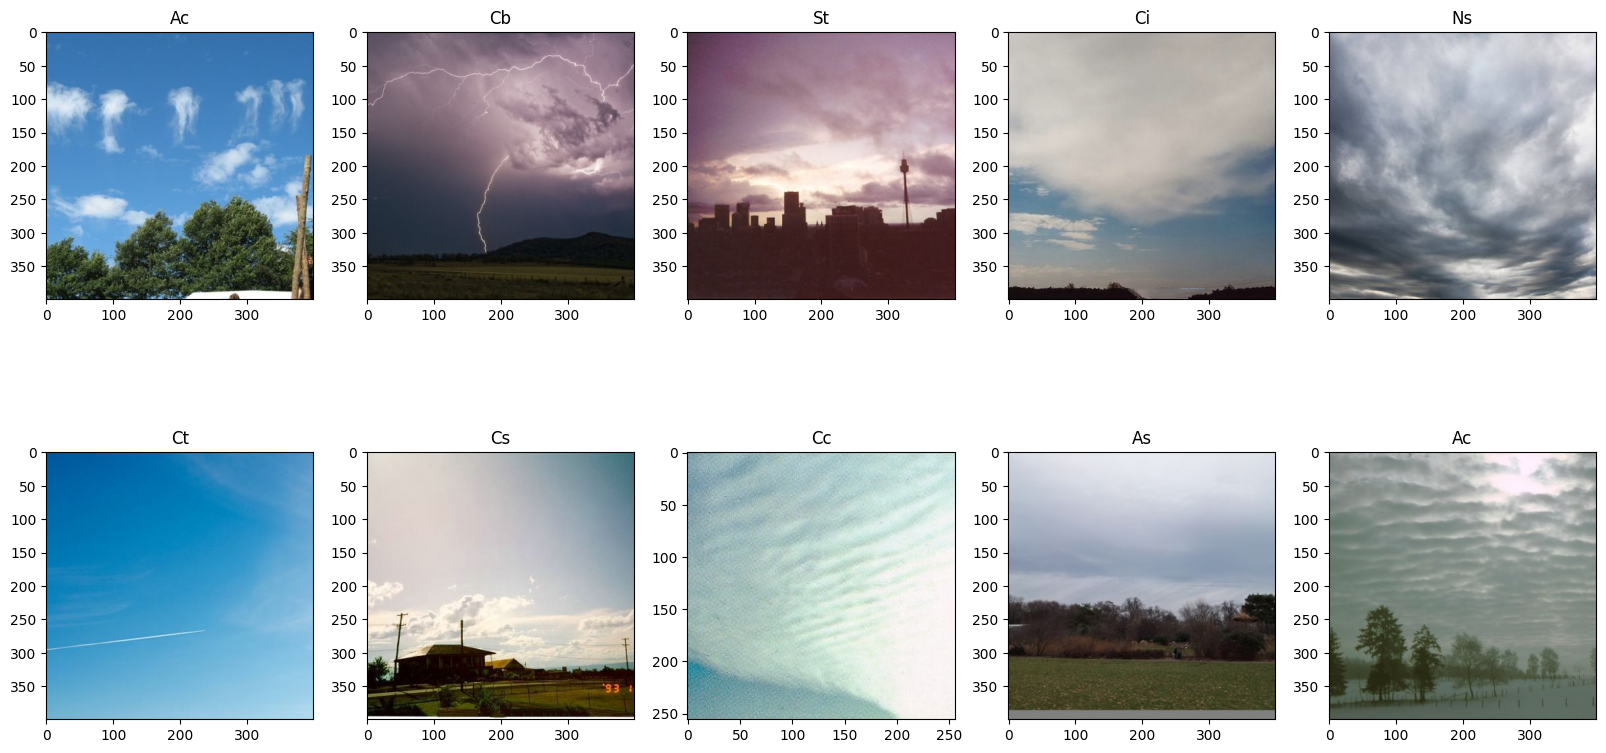

In [7]:
import matplotlib.pyplot as plt
import glob
from PIL import Image

test_file_list = glob.glob(f'{test_root}/*/*')
random.shuffle(test_file_list)

plt.figure(figsize=(20, 10))
for i in range(10):
  test_img_path = test_file_list[i]
  ori_img = Image.open(test_img_path)
  plt.subplot(2, 5, i+1)
  plt.imshow(ori_img)
  plt.title(test_img_path.split('/')[-2])
plt.show()

## 2. 데이터 전처리

In [8]:
import os
import torch
import torchvision
from torchvision import datasets, transforms

In [9]:
IMG_SIZE = 64

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize(IMG_SIZE),
        transforms.RandomApply([transforms.RandomHorizontalFlip(0.5),
                                transforms.RandomRotation(degrees=(-15, 15)),
                                transforms.RandomAffine(degrees=0, translate=(0.1, 0.1))], p=0.5),
        transforms.ColorJitter(brightness=(0.5, 0.9), contrast=(0.4, 0.8), saturation=(0.7, 0.9), hue=(-0.2,0.2)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'valid': transforms.Compose([
        transforms.Resize(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}



In [10]:
image_datasets = {x: datasets.ImageFolder(os.path.join(data_root, x),
                                          data_transforms[x])
                                          for x in ['train', 'valid', 'test']
                  }

data_loaders = {x: torch.utils.data.DataLoader(image_datasets[x],
                                               batch_size=16,
                                               shuffle=True,
                                               num_workers=4)
                                              for x in ['train', 'valid', 'test']
                }

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'valid', 'test']}
class_names = image_datasets['train'].classes

print(f'class_names: {class_names}')
print(f'dataset_sizes: {dataset_sizes}')

class_names: ['Ac', 'As', 'Cb', 'Cc', 'Ci', 'Cs', 'Ct', 'Cu', 'Ns', 'Sc', 'St']
dataset_sizes: {'train': 1863, 'valid': 232, 'test': 228}


## 3. Training

In [14]:
import os
import torch
import torch.nn.functional as F
from tempfile import TemporaryDirectory
from time import time
from tqdm import tqdm
import timm

import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torch.optim import lr_scheduler

In [12]:
def train_model(model, criterion, optimizer, scheduler, dataloaders, dataset_sizes, device, model_dir, model_name, num_epochs=25):
    print(device)  # 현재 학습이 실행되는 장치(CPU/GPU) 출력
    since = time()  # 학습 시작 시간 기록

    # 임시 디렉토리를 만들어 모델 체크포인트를 저장 (훈련 중에만 임시로 사용)
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)  # 모델 초기 파라미터 저장
        best_acc = 0.0  # 현재까지의 최고 검증 정확도
        train_loss = []  # epoch별 train loss 기록
        train_acc = []   # epoch별 train acc 기록
        valid_loss = []  # epoch별 valid loss 기록
        valid_acc = []   # epoch별 valid acc 기록

        # 전체 epoch 반복
        for epoch in range(num_epochs):
            print(f'Epoch {epoch+1}/{num_epochs}')
            print('-' * 10)

            # 각 epoch에서 train, valid 두 단계 실행
            for phase in ['train', 'valid']:
                if phase == 'train':
                    model.train()  # 학습 모드 (dropout, BN 등 활성화)
                else:
                    model.eval()   # 평가 모드 (dropout, BN 고정)

                running_loss = 0.0       # 한 epoch 동안의 손실 누적
                running_corrects = 0     # 한 epoch 동안 맞춘 샘플 수 누적

                # 배치 단위로 데이터 가져오기
                for inputs, labels in tqdm(dataloaders[phase]):
                    inputs = inputs.to(device)  # 입력 데이터를 GPU/CPU로 이동
                    labels = labels.to(device)  # 라벨도 GPU/CPU로 이동

                    optimizer.zero_grad()  # 이전 배치에서 계산된 기울기 초기화

                    # forward 연산
                    with torch.set_grad_enabled(phase == 'train'):
                        # train일 때만 gradient 계산, valid일 때는 계산 안 함(속도 ↑)
                        outputs = model(inputs)          # 모델 출력값
                        _, preds = torch.max(outputs, 1) # 예측 클래스 (argmax)
                        loss = criterion(outputs, labels) # 손실 함수 계산

                        # train 단계에서는 backpropagation + optimizer step
                        if phase == 'train':
                            loss.backward()  # 기울기 역전파
                            optimizer.step() # 파라미터 업데이트

                    # 통계 기록
                    running_loss += loss.item() * inputs.size(0)  # 배치 손실 합산
                    running_corrects += torch.sum(preds == labels.data)  # 맞춘 개수 합산

                # 스케줄러(stepLR 등)가 있으면 train 단계 끝에서 step 실행
                if scheduler is not None and phase == 'train':
                    scheduler.step()

                # epoch 단위 평균 손실/정확도 계산
                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                # 로그 출력
                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # 학습 결과 저장
                if phase == 'train':
                    train_loss.append(epoch_loss)
                    train_acc.append(epoch_acc.item())
                else:
                    valid_loss.append(epoch_loss)
                    valid_acc.append(epoch_acc.item())

                    # best model 업데이트 (검증 정확도가 더 높을 때)
                    if epoch_acc > best_acc:
                        best_acc = epoch_acc

                        # 모델 저장 경로가 없으면 생성
                        if not os.path.exists(model_dir):
                            os.makedirs(model_dir)

                        # 모델 저장 (best model 파라미터 저장)
                        model_save_path = os.path.join(model_dir, f'{model_name}.pth')
                        torch.save(model.state_dict(), model_save_path)

            print()

        # 전체 학습 시간 출력
        time_elapsed = time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:.4f}')

    # 학습/검증 손실 및 정확도 리스트 반환
    return [train_loss, valid_loss, train_acc, valid_acc]


In [13]:
pjt_root = '/content/drive/MyDrive/Cv79_pj/Cloud/models'
model_dir = f'{pjt_root}/models'
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(DEVICE)
NUM_EPOCHS = 100

cuda:0


In [17]:
num_class = len(os.listdir(train_root))
print(f'Number of Class: {num_class}')
resnet18_model = timm.create_model('resnet18', pretrained=True, num_classes=num_class).to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(resnet18_model.parameters(), lr=0.0001)
scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.9)

Number of Class: 11


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

In [18]:
num_epochs = NUM_EPOCHS
resnet18 = train_model(resnet18_model, criterion, optimizer, scheduler, data_loaders, dataset_sizes, DEVICE, model_dir, 'resnet18', num_epochs)

cuda:0
Epoch 1/100
----------


100%|██████████| 117/117 [00:05<00:00, 20.91it/s]


train Loss: 2.3888 Acc: 0.1165


100%|██████████| 15/15 [00:00<00:00, 25.55it/s]


valid Loss: 2.3598 Acc: 0.1724

Epoch 2/100
----------


...

valid Loss: 2.3921 Acc: 0.3664

Epoch 100/100
----------


100%|██████████| 117/117 [00:04<00:00, 28.61it/s]


train Loss: 0.7216 Acc: 0.7633


100%|██████████| 15/15 [00:00<00:00, 25.41it/s]

valid Loss: 2.3413 Acc: 0.3750

Training complete in 7m 51s
Best val Acc: 0.4310


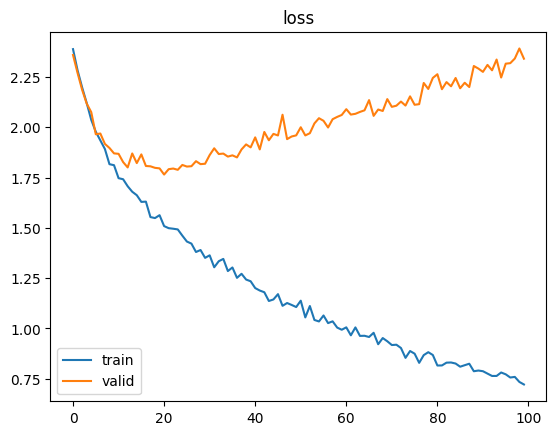

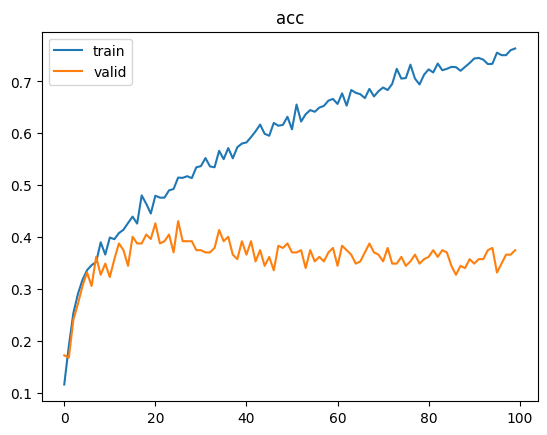

In [19]:
import matplotlib.pyplot as plt

plt.title("loss")
plt.plot(resnet18[0], label='train')
plt.plot(resnet18[1], label='valid')
plt.legend()
plt.show()

plt.title("acc")
plt.plot(resnet18[2], label='train')
plt.plot(resnet18[3], label='valid')
plt.legend()
plt.show()

In [20]:
print(resnet18)

[[2.388835198253441, 2.283304879310882, 2.1986123699688873, 2.12136245029816, 2.037397988304552, 1.9780683868109252, 1.9350261155853845, 1.8921948798676684, 1.8168190047744777, 1.8118061271970527, 1.7472552228728995, 1.7419839265585841, 1.7071386679998983, 1.6798690293210203, 1.662622762379055, 1.629307184882274, 1.6306939261994948, 1.55384978963941, 1.5488759898013218, 1.5632482994261827, 1.5090166476869609, 1.4986879938850464, 1.4959202801355802, 1.4924570480086634, 1.4615966701021261, 1.4322291937043317, 1.421884237792117, 1.3802287504356905, 1.3900786253693151, 1.3510638596994928, 1.3636942253404578, 1.3042618562249937, 1.3343853838201882, 1.3458735687529215, 1.2854761741395542, 1.3033289474885565, 1.2517647465518003, 1.2718104400496553, 1.2432633351076692, 1.2346727540271614, 1.2008730102724372, 1.1886584402986322, 1.1801215604755486, 1.136657135690084, 1.1442636063325424, 1.1706566254553843, 1.1126396537978869, 1.1265410612938678, 1.1170058072541136, 1.1065561978073448, 1.1381860

In [25]:
num_class = len(os.listdir(train_root))
print(f'Number of Class: {num_class}')
resnet34_model = timm.create_model('resnet34', pretrained=True, num_classes=num_class).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet34_model.parameters(), lr=0.0001)
scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.9)

Number of Class: 11


In [26]:
num_epochs = NUM_EPOCHS
resnet34 = train_model(resnet34_model, criterion, optimizer,scheduler, data_loaders, dataset_sizes, DEVICE, model_dir, 'cloud_resnet34', num_epochs =num_epochs)

cuda:0
Epoch 1/100
----------


100%|██████████| 117/117 [00:04<00:00, 29.00it/s]


train Loss: 2.4035 Acc: 0.1181


100%|██████████| 15/15 [00:00<00:00, 25.31it/s]


valid Loss: 2.3772 Acc: 0.1078

Epoch 2/100
----------


...

valid Loss: 2.2151 Acc: 0.3664

Epoch 100/100
----------


100%|██████████| 117/117 [00:03<00:00, 29.41it/s]


train Loss: 0.7123 Acc: 0.7585


100%|██████████| 15/15 [00:00<00:00, 25.81it/s]

valid Loss: 2.2603 Acc: 0.3966

Training complete in 8m 6s
Best val Acc: 0.4095


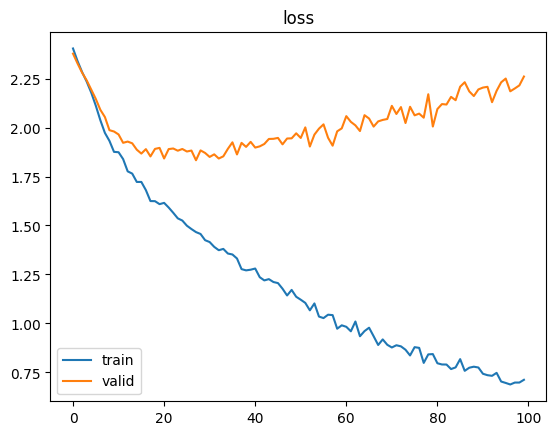

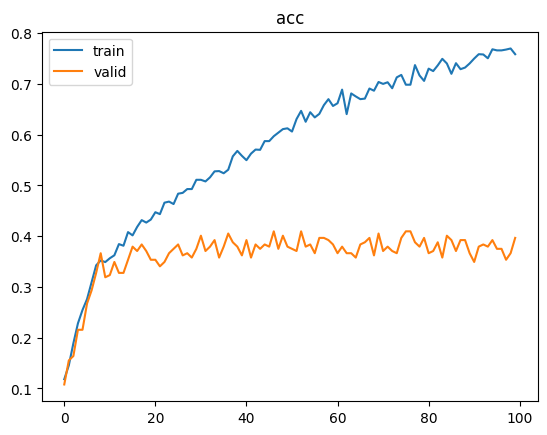

In [27]:
import matplotlib.pyplot as plt

plt.title("loss")
plt.plot(resnet34[0], label='train')
plt.plot(resnet34[1], label='valid')
plt.legend()
plt.show()

plt.title("acc")
plt.plot(resnet34[2], label='train')
plt.plot(resnet34[3], label='valid')
plt.legend()
plt.show()

In [28]:
print(resnet34)

[[2.4035221721559075, 2.3388630918962496, 2.2830039559035167, 2.234392137215205, 2.1782392425301635, 2.111627884277143, 2.0373566259444558, 1.9726410793861393, 1.93181753811245, 1.875794251119969, 1.8739188334920107, 1.8389921794958928, 1.7763727423457516, 1.7647998897989654, 1.722253393627787, 1.7223150444107547, 1.6804105050449913, 1.624672205487823, 1.6241310773456346, 1.6089384075268198, 1.6154499428283766, 1.591701258463816, 1.5649036622085817, 1.5364713298333823, 1.5251538463004866, 1.498916463063599, 1.4818235507141948, 1.4662892010284891, 1.4566615869841522, 1.4249481888976843, 1.4154421299679971, 1.3909087485673284, 1.373796391474324, 1.3804575157498264, 1.3568649767421614, 1.3519811267438142, 1.3315484795081507, 1.2772796635210546, 1.2709005383221743, 1.2742998663354035, 1.2803083458576416, 1.2359304193265324, 1.2196660619619004, 1.226192969950821, 1.2114077838466684, 1.2059675905567564, 1.177264848768999, 1.1427355227902956, 1.1711506092350008, 1.1361954818793156, 1.12111321

In [29]:
num_class = len(os.listdir(train_root))
print(f'Number of Class: {num_class}')
resnet50_model = timm.create_model('resnet50', pretrained=True, num_classes= num_class).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet50_model.parameters(), lr=0.0001)
scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.9)

Number of Class: 11


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

In [31]:
num_epochs = NUM_EPOCHS
resnet50 = train_model(resnet50_model, criterion, optimizer,scheduler, data_loaders, dataset_sizes, DEVICE, model_dir, 'cloud_resnet50', num_epochs =num_epochs)

cuda:0
Epoch 1/100
----------


100%|██████████| 117/117 [00:04<00:00, 26.69it/s]


train Loss: 2.3769 Acc: 0.1235


100%|██████████| 15/15 [00:00<00:00, 24.86it/s]


valid Loss: 2.8502 Acc: 0.1250

Epoch 2/100
----------


...

valid Loss: 4.7243 Acc: 0.3793

Epoch 100/100
----------


100%|██████████| 117/117 [00:04<00:00, 25.88it/s]


train Loss: 0.5185 Acc: 0.8175


100%|██████████| 15/15 [00:00<00:00, 23.10it/s]

valid Loss: 2.6346 Acc: 0.4009

Training complete in 8m 34s
Best val Acc: 0.4267


In [32]:
print(resnet50)

[[2.3768853949271924, 2.3193159375981622, 2.2648501690523126, 2.1811894493210526, 2.0837590108939033, 1.9745782304693151, 1.9072278346416456, 1.8345776525032629, 1.7948843054533388, 1.7363613955896513, 1.7344737265357009, 1.670267242036452, 1.6341534116481877, 1.6416103115532261, 1.61354054402614, 1.5747672567684934, 1.563642784529198, 1.545018870473484, 1.5090357968068802, 1.5079963569415875, 1.4142559331012425, 1.4562155360568934, 1.451678082946802, 1.3990266126647024, 1.3882754652716431, 1.3797492679574448, 1.3627309860622634, 1.3174091066907185, 1.3380095097433797, 1.3121369357270318, 1.3000854331834049, 1.305918013288075, 1.232682402263197, 1.2190928824537874, 1.2057340630138682, 1.194839366424231, 1.1797955288275301, 1.1881628469696495, 1.1435961648461899, 1.1498819349020704, 1.1011069408041523, 1.086610600568246, 1.0827356512931745, 1.0665838346645131, 1.0496292749016884, 1.0258836862673635, 1.0176004786294313, 1.0321739802613927, 0.9982419473089585, 1.0095147319973892, 0.968777

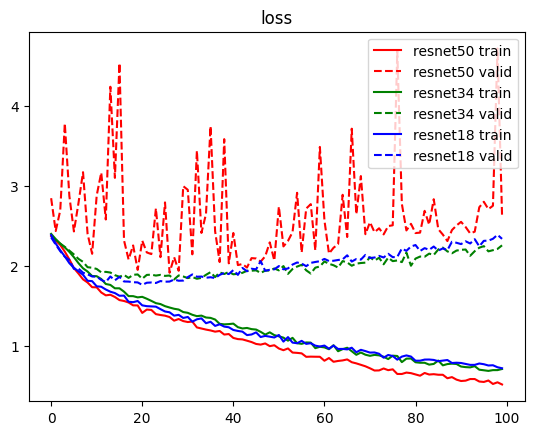

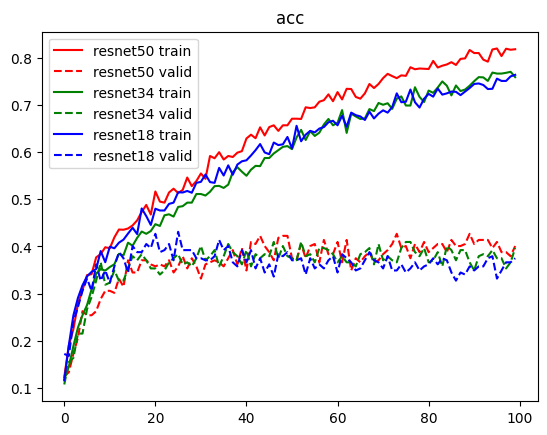

In [33]:
import matplotlib.pyplot as plt

plt.title("loss")
plt.plot(resnet50[0],'r-', label='resnet50 train')
plt.plot(resnet50[1],'r--', label='resnet50 valid')
plt.plot(resnet34[0],'g-', label='resnet34 train')
plt.plot(resnet34[1],'g--', label='resnet34 valid')
plt.plot(resnet18[0],'b-', label='resnet18 train')
plt.plot(resnet18[1],'b--', label='resnet18 valid')
plt.legend()
plt.show()

plt.title("acc")
plt.plot(resnet50[2],'r-', label='resnet50 train')
plt.plot(resnet50[3],'r--', label='resnet50 valid')
plt.plot(resnet34[2],'g-', label='resnet34 train')
plt.plot(resnet34[3],'g--', label='resnet34 valid')
plt.plot(resnet18[2],'b-', label='resnet18 train')
plt.plot(resnet18[3],'b--', label='resnet18 valid')
plt.legend()
plt.show()

## 4. Testing

In [40]:
import os
import torch
import torch.nn.functional as F
from tempfile import TemporaryDirectory
from time import time
from tqdm import tqdm
import random

import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torchvision.models as models
from torchvision import datasets, transforms
import time

from PIL import Image
import matplotlib.pyplot as plt
import glob

In [35]:
data_root = '/content/drive/MyDrive/Cv79_pj/Cloud'
pjt_root = '/content/drive/MyDrive/Cv79_pj/Cloud/models'
test_root = f'{data_root}/test'
test_file_list = glob.glob(f'{test_root}/*/*')
random.shuffle(test_file_list)

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda:0


In [36]:
test_data_transform = transforms.Compose([
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

image_test = datasets.ImageFolder(os.path.join(data_root, 'test'), test_data_transform)
test_dataloaders = torch.utils.data.DataLoader(image_test, batch_size=16, shuffle=False, num_workers=0)

test_dataset_size = len(image_test)
class_names = image_test.classes

In [44]:
from time import time

def test_model(model, criterion, dataloader, dataset_size, device):
    print(device)                     # 현재 학습/평가에 사용할 장치(GPU/CPU) 출력
    since = time()                    # 테스트 시작 시간 기록

    model.eval()                      # 모델을 평가 모드로 설정 (Dropout, BatchNorm 고정)

    running_loss = 0.0                # 테스트 전체 손실값 누적
    running_corrects = 0              # 맞춘 샘플 개수 누적

    # 데이터셋을 배치 단위로 반복
    for inputs, labels in tqdm(dataloader):
        inputs = inputs.to(device)    # 입력 이미지를 GPU/CPU로 이동
        labels = labels.to(device)    # 라벨을 GPU/CPU로 이동

        with torch.no_grad():         # 평가 단계에서는 gradient 계산을 비활성화 (속도 ↑, 메모리 ↓)
            outputs = model(inputs)   # 모델 예측값
            _, preds = torch.max(outputs, 1)   # 가장 높은 확률의 클래스 인덱스 선택
            loss = criterion(outputs, labels)  # 손실값 계산

        # 통계값 계산
        running_loss += loss.item() * inputs.size(0)  # 배치 손실 합산
        running_corrects += torch.sum(preds == labels.data)  # 맞춘 개수 합산

    # 전체 데이터셋에 대한 평균 손실과 정확도 계산
    epoch_loss = running_loss / dataset_size
    epoch_acc = running_corrects.double() / dataset_size

    # 총 테스트 소요 시간 출력
    time_elapsed = time() - since
    print(f'Test complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Acc: {epoch_acc:.4f} Loss: {epoch_loss:.4f}')

In [38]:
num_class = len(os.listdir(test_root))
resnet18_model = timm.create_model('resnet18', pretrained=False, num_classes=num_class).to(DEVICE)

cp_path = f"{pjt_root}/models/resnet18.pth"
resnet18_model.load_state_dict(torch.load(cp_path, map_location=DEVICE))

<All keys matched successfully>

In [45]:
criterion = nn.CrossEntropyLoss()
test_model(resnet18_model, criterion, test_dataloaders, test_dataset_size, DEVICE)

cuda:0


100%|██████████| 15/15 [00:01<00:00, 14.18it/s]

Test complete in 0m 1s
Acc: 0.3333 Loss: 1.8910


In [46]:
idx = 10

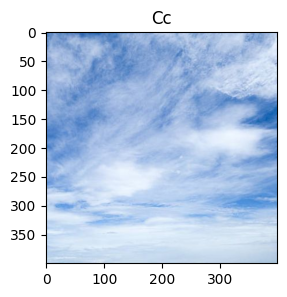

In [50]:
test_img_path = os.path.join(test_root, test_file_list[idx])
ori_img = Image.open(test_img_path).convert('RGB')
image = test_data_transform(ori_img)
x_tensor = image.to(DEVICE).unsqueeze(0)

outputs = resnet18_model(x_tensor)
_, y_pred = torch.max(outputs, 1)

plt.figure(figsize=(3, 3))
plt.title(class_names[y_pred])
plt.imshow(ori_img)
plt.show()